# Notebook 2: Coverage, Diversity, and Novelty Metrics

**Goal (RQ4 from the proposal):** The proposal listed Coverage, Diversity, and Novelty as required list-health metrics alongside Recall/NDCG. 

Run **after** notebook 1, which writes `outputs/promo_reranked_recommendations.csv`.

## Metric definitions

| Metric | Definition |
|---|---|
| **Coverage@K** | Fraction of unique products in the candidate pool ever recommended across all events at cutoff K |
| **Intra-List Diversity (ILD)@K** | Average pairwise category dissimilarity within each event's top-K list, then averaged over all events. Dissimilarity = 1 if two items have different `product_category`, else 0 |
| **Novelty@K** | Average self-information of recommended items: $-\log_2(\text{popularity}(i))$ where popularity is the fraction of events in which product $i$ appears in the full candidate pool |

We compare the **promotion-aware reranking** (from `promo_reranked_recommendations.csv`) against the **tail-fusion baseline** it is built on (from `candidates_coupon_response_tail_fusion.csv`) to see how the business reranking layer changes list health. This is the same flow as notebook 1 / `scripts/run_coupon_response_reranking.py` (XGBoost primary → tail fusion → reranking).

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

OUTPUTS = "../outputs"

recs = pd.read_csv(f"{OUTPUTS}/promo_reranked_recommendations.csv")          # promotion-aware reranking (notebook 1 output)
tf   = pd.read_csv(f"{OUTPUTS}/candidates_coupon_response_tail_fusion.csv")  # tail-fusion baseline

# The tail-fusion file already has a `rank` column (== final_rank), so no rename is needed.

print(f"Promo-aware reranking rows: {len(recs):,}")
print(f"Tail fusion rows: {len(tf):,}")

Promo-aware reranking rows: 44,760
Tail fusion rows: 44,760


## 1. Coverage@K

How broadly does the recommender spread recommendations across the product catalogue?

In [21]:
def coverage_at_k(df, k, split="test"):
    """Fraction of unique candidate products that appear in at least one top-K list."""
    sub = df[df["split"] == split]
    total_unique = sub["product_id"].nunique() # all products in the candidate pool
    recommended  = sub[sub["rank"] <= k]["product_id"].nunique()
    return recommended / total_unique if total_unique > 0 else 0.0


k_values = [5, 10, 20]
rows = []
for split in ["validation", "test"]:
    for k in k_values:
        rows.append({
            "Model": "Promo-Aware Reranking",
            "Split": split,
            "K": k,
            "Coverage@K": round(coverage_at_k(recs, k, split), 4),
        })
        rows.append({
            "Model": "Tail Fusion",
            "Split": split,
            "K": k,
            "Coverage@K": round(coverage_at_k(tf, k, split), 4),
        })

cov_df = pd.DataFrame(rows)
print("Coverage@K\n")
print(cov_df.pivot_table(index=["Model", "Split"], columns="K", values="Coverage@K").to_string())

Coverage@K

K                                     5       10   20
Model                 Split                          
Promo-Aware Reranking test        0.7137  0.8442  1.0
                      validation  0.4693  0.7094  1.0
Tail Fusion           test        0.7058  0.8529  1.0
                      validation  0.4680  0.7092  1.0


## 2. Intra-List Diversity (ILD)@K

For each event's top-K list, we measure how many product-pairs belong to *different* `product_category` groups. A high ILD means recommendations span multiple categories — better for discovery.

In [22]:
def ild_at_k(df, k, category_col="product_category", split="test"):
    """
    Intra-List Diversity@K averaged over events.
    ILD per event = fraction of distinct item-pairs in top-K with different categories.
    """
    sub = df[(df["split"] == split) & (df["rank"] <= k)]
    event_ilds = []

    for _, group in sub.groupby("event_id"):
        cats = group[category_col].values
        if len(cats) < 2:
            event_ilds.append(0.0)
            continue
        # pairwise dissimilarity: 1 if different categories, 0 if same
        n_pairs    = 0
        n_dissim   = 0
        for i in range(len(cats)):
            for j in range(i + 1, len(cats)):
                n_pairs  += 1
                n_dissim += int(cats[i] != cats[j])
        event_ilds.append(n_dissim / n_pairs)

    return np.mean(event_ilds) if event_ilds else 0.0


rows = []
for split in ["validation", "test"]:
    for k in k_values:
        rows.append({
            "Model": "Promo-Aware Reranking",
            "Split": split,
            "K": k,
            "ILD@K": round(ild_at_k(recs, k, split=split), 4),
        })
        rows.append({
            "Model": "Tail Fusion",
            "Split": split,
            "K": k,
            "ILD@K": round(ild_at_k(tf, k, split=split), 4),
        })

ild_df = pd.DataFrame(rows)
print("Intra-List Diversity@K (higher = more diverse category mix)")
print(ild_df.pivot_table(index=["Model", "Split"], columns="K", values="ILD@K").to_string())

Intra-List Diversity@K (higher = more diverse category mix)
K                                     5       10      20
Model                 Split                             
Promo-Aware Reranking test        0.6989  0.7141  0.6648
                      validation  0.8559  0.8735  0.8849
Tail Fusion           test        0.6596  0.6808  0.6648
                      validation  0.8469  0.8725  0.8849


## 3. Novelty@K

Novelty measures how *unexpected* the recommended items are. Popular items that appear in many households' candidate lists have low novelty. A higher novelty score means the model surfaces less-obvious coupon products.

We define item popularity as the fraction of events (within a split) where a product appears in the candidate pool.

In [23]:
def novelty_at_k(df, k, split="test"):
    """
    Novelty@K = mean -log2(popularity(i)) over top-K recommended items.
    popularity(i) = fraction of events in which product i appears in the candidate pool.
    """
    sub = df[df["split"] == split]
    n_events = sub["event_id"].nunique()

    # popularity: how many events include this product as a candidate
    pop = (
        sub.groupby("product_id")["event_id"]
        .nunique()
        .rename("event_count")
        / n_events
    ).rename("popularity")

    top_k = sub[sub["rank"] <= k].merge(pop, on="product_id", how="left")
    # clip to avoid log(0); products with p=1 get novelty=0
    top_k["novelty"] = -np.log2(top_k["popularity"].clip(lower=1e-9))

    return top_k.groupby("event_id")["novelty"].mean().mean()


rows = []
for split in ["validation", "test"]:
    for k in k_values:
        rows.append({
            "Model": "Promo-Aware Reranking",
            "Split": split,
            "K": k,
            "Novelty@K": round(novelty_at_k(recs, k, split=split), 4),
        })
        rows.append({
            "Model": "Tail Fusion",
            "Split": split,
            "K": k,
            "Novelty@K": round(novelty_at_k(tf, k, split=split), 4),
        })

nov_df = pd.DataFrame(rows)
print("Novelty@K (higher = recommends less-popular, more surprising coupon products)")
print(nov_df.pivot_table(index=["Model", "Split"], columns="K", values="Novelty@K").to_string())

Novelty@K (higher = recommends less-popular, more surprising coupon products)
K                                     5       10      20
Model                 Split                             
Promo-Aware Reranking test        4.8922  4.4467  3.8528
                      validation  5.4729  5.6585  5.8505
Tail Fusion           test        4.9421  4.5052  3.8528
                      validation  5.4565  5.6549  5.8505


## 4. Full summary table

In [24]:
summary_rows = []
for model_name, df in [("Promo-Aware Reranking", recs), ("Tail Fusion", tf)]:
    for split in ["validation", "test"]:
        for k in k_values:
            summary_rows.append({
                "Model":      model_name,
                "Split":      split,
                "K":          k,
                "Coverage":   round(coverage_at_k(df, k, split), 4),
                "ILD":        round(ild_at_k(df, k, split=split), 4),
                "Novelty":    round(novelty_at_k(df, k, split=split), 4),
            })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

summary.to_csv(f"{OUTPUTS}/diversity_coverage_novelty.csv", index=False)
print("\nSaved to outputs/diversity_coverage_novelty.csv")

                Model      Split  K  Coverage    ILD  Novelty
Promo-Aware Reranking validation  5    0.4693 0.8559   5.4729
Promo-Aware Reranking validation 10    0.7094 0.8735   5.6585
Promo-Aware Reranking validation 20    1.0000 0.8849   5.8505
Promo-Aware Reranking       test  5    0.7137 0.6989   4.8922
Promo-Aware Reranking       test 10    0.8442 0.7141   4.4467
Promo-Aware Reranking       test 20    1.0000 0.6648   3.8528
          Tail Fusion validation  5    0.4680 0.8469   5.4565
          Tail Fusion validation 10    0.7092 0.8725   5.6549
          Tail Fusion validation 20    1.0000 0.8849   5.8505
          Tail Fusion       test  5    0.7058 0.6596   4.9421
          Tail Fusion       test 10    0.8529 0.6808   4.5052
          Tail Fusion       test 20    1.0000 0.6648   3.8528

Saved to outputs/diversity_coverage_novelty.csv


## 5. Visualisation

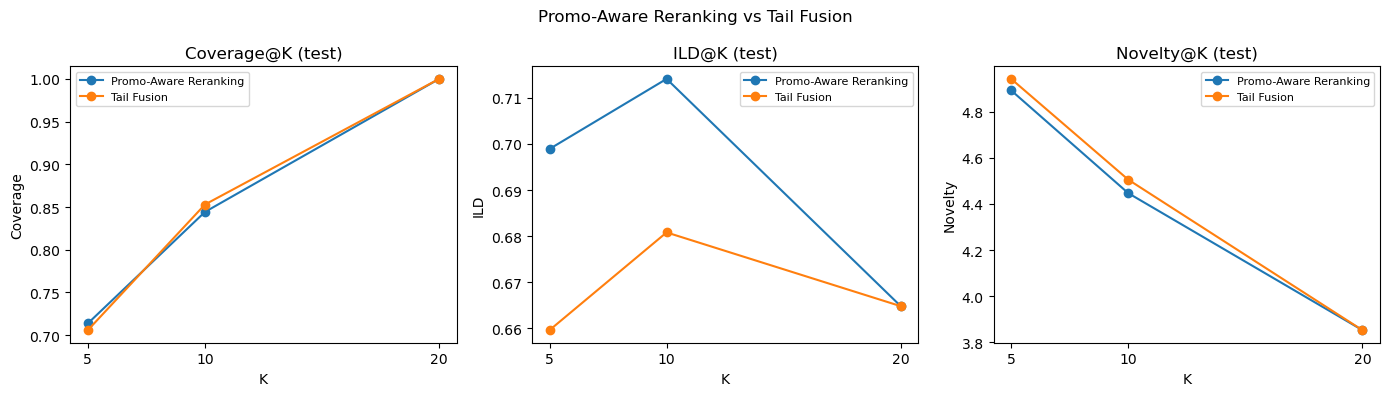

In [25]:
test_summary = summary[summary["Split"] == "test"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["Coverage", "ILD", "Novelty"]

for ax, metric in zip(axes, metrics):
    for model, grp in test_summary.groupby("Model"):
        ax.plot(grp["K"], grp[metric], marker="o", label=model)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric}@K (test)")
    ax.set_xticks(k_values)
    ax.legend(fontsize=8)

plt.suptitle("Promo-Aware Reranking vs Tail Fusion", fontsize=12)
plt.tight_layout()
# plt.savefig(f"{OUTPUTS}/diversity_coverage_novelty_plot.png", dpi=150)
plt.show()

## 6. Summary

We compare the **promotion-aware reranking** against the **tail-fusion** ranker it is built on, to isolate what the business reranking layer does to list health.

### Results (test split)

| Metric | Model | K=5 | K=10 | K=20 |
|---|---|---|---|---|
| Coverage | Promo-Aware Reranking | 0.7137 | 0.8442 | 1.0000 |
| Coverage | Tail Fusion | 0.7058 | 0.8529 | 1.0000 |
| ILD | Promo-Aware Reranking | 0.6989 | 0.7141 | 0.6648 |
| ILD | Tail Fusion | 0.6596 | 0.6808 | 0.6648 |
| Novelty | Promo-Aware Reranking | 4.8922 | 4.4467 | 3.8528 |
| Novelty | Tail Fusion | 4.9421 | 4.5052 | 3.8528 |

### Key findings

**1. All three metrics are identical at K=20 — because each event has exactly 20 candidates.**
With 20 candidates per event, the top-20 *is* the full candidate set, so Coverage, ILD, and Novelty at K=20 are set-based and unaffected by reordering. The reranking only changes anything at K=5 and K=10.

**2. The diversity term raises intra-list diversity (the intended RQ4 effect).**
The reranking's explicit diversity term (ρ=0.1, rewarding category rarity) measurably increases ILD over the tail-fusion baseline at K=5 (0.6596 → 0.6989) and K=10 (0.6808 → 0.7141) — roughly +0.033 at K=10, meaning about 71% of top-10 product-pairs now span different categories. This is the business layer doing what it is designed to do: spread the top-10 across more categories.

**3. Coverage is essentially unchanged.**
At K=5 the reranking is marginally wider (0.7137 vs 0.7058) and at K=10 marginally narrower (0.8442 vs 0.8529) — differences of ~1 percentage point in either direction, i.e. the business layer does not meaningfully change how much of the catalogue is surfaced.

**4. Novelty dips slightly under reranking.**
Novelty is a touch lower at K=5 (4.8922 vs 4.9421) and K=10 (4.4467 vs 4.5052). The diversity term promotes rarer-*category* products, but those are not necessarily globally less-popular *items*, so average self-information drops a little. On the validation split novelty instead rises with K (5.46 → 5.85), consistent with the known validation/test distribution shift (test campaigns have fewer positive events and a different popularity profile).

**5. Addressing RQ4.**
The proposal asked whether diversity control improves recommendation list health. **Yes:** the explicit diversity term in the promotion-aware reranking raises ILD@5 and ILD@10 over the tail-fusion baseline at negligible cost to coverage and only a small novelty dip. The effect is modest (ρ=0.1 is a light touch, chosen by the grid search to protect NDCG@10); a larger ρ or a hard per-category cap in the top-K would push diversity further if that became a priority. Even so, the ~0.71 ILD at K=10 indicates the reranked lists are well spread across categories.